In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
  accuracy_score,
  confusion_matrix,
  classification_report,
  roc_curve,
  roc_auc_score
)

In [2]:
data = pd.read_csv("Titanic-Dataset.csv")

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.shape

(891, 12)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [10]:
data = data[["Survived","Pclass","Age","Fare"]]

In [11]:
data.head()

,Survived,Pclass,Age,Fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


In [12]:
# Pclass= clase de pasajero 
# Age = wsS 
# Fare = tarifa 
# Survived = SI - NO 

In [13]:
# Limpieza de data 

In [14]:
data.isnull().sum()

Survived      0
Pclass        0
Age         177
Fare          0
dtype: int64

In [15]:
data = data.dropna()

In [16]:
data.isnull().sum()

Survived    0
Pclass      0
Age         0
Fare        0
dtype: int64

In [17]:
data["Age"].mean()

np.float64(29.69911764705882)

In [18]:
data["Age"].median()

28.0

In [19]:
data["Fare"].mean()

np.float64(34.694514005602244)

In [20]:
data[["Age", "Fare"]].std() # desviacion estandar 

Age     14.526497
Fare    52.918930
dtype: float64

In [21]:
X = data[["Pclass","Age","Fare"]]
y = data["Survived"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba", y_test.shape)

Datos de entrenamiento: (571, 3)
Datos de prueba (143,)


In [23]:
# normalizar 

In [24]:
scaler = StandardScaler()

In [25]:
X_train_scaled = scaler.fit_transform(X_train)
y_test_scaled = scaler.transform(X_test)

In [26]:
# entrenamiento de modelo SVM con GAMMA 

In [30]:
modelo = SVC (
    kernel="rbf", #permitir que SVM encuentre la frontera no lineales
    C=1, #controlar el equilibrio entre un frontera y los errores de clasificacion
    gamma=0.1, #Controlar que tan lejos llega la influencia de cada punto 
    probability=True 
)
modelo.fit(X_train_scaled, y_train)


NameError: name 'X_test_scaled' is not defined

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
y_test_scaled = scaler.transform(X_test)

In [33]:
X_test_scaled = scaler.fit_transform(X_test)


In [34]:
# prediccion 
y_pred = modelo.predict(X_test_scaled)

In [35]:
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [36]:
# 0 = no sobrevivio 
# 1 = si sobrevivio 

In [37]:
accuracy = accuracy_score(y_test,y_pred)

In [38]:
print("\nAccuraccy:",accuracy)


Accuraccy: 0.6643356643356644


In [40]:
cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusion ")
print(cm)


Matriz de confusion 
[[68 17]
 [31 27]]


In [41]:
print("\nReporte de Clasificacion")
print(classification_report(y_test,y_pred))


Reporte de Clasificacion
              precision    recall  f1-score   support

           0       0.69      0.80      0.74        85
           1       0.61      0.47      0.53        58

    accuracy                           0.66       143
   macro avg       0.65      0.63      0.63       143
weighted avg       0.66      0.66      0.65       143



In [42]:
# probabilidades 
prob = modelo.predict_proba(X_test_scaled)[:,1]
print("\nPrimeras probabilidades")
print(prob[:10])


Primeras probabilidades
[0.23813348 0.23103763 0.24947256 0.41622813 0.24030325 0.23818001
 0.23765848 0.23970179 0.40153193 0.60664364]


In [43]:
# ROC - AUC 
fpr, tpr, thresholds = roc_curve(y_test, prob)
auc = roc_auc_score(y_test, prob)
print("\nROC-AUC",auc)


ROC-AUC 0.7170385395537525


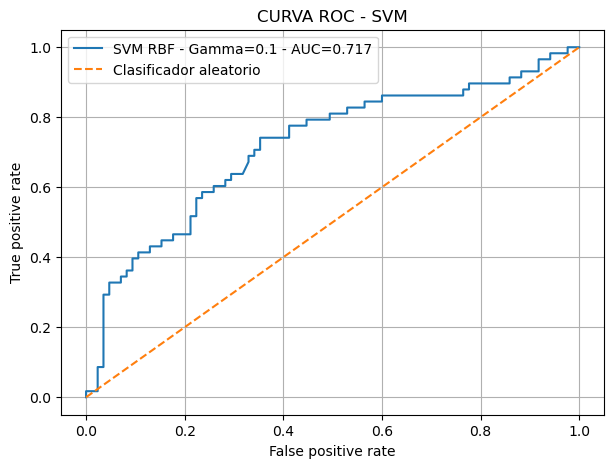

In [46]:
# grafica
plt.figure(figsize=(7,5))
plt.plot(
    fpr,
    tpr,
    label=f"SVM RBF - Gamma=0.1 - AUC={auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label ="Clasificador aleatorio"
)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("CURVA ROC - SVM")
plt.legend()
plt.grid()

plt.show()